In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('cars_data_post_eda.csv')

In [ ]:
df1 = pd.read_csv('cars_data_cleaned1_post_model_selection.csv')

In [ ]:
df1[df1['region'] == 'neem-ka-thana']

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age


In [ ]:
df[df['model'] == 'tt']

In [ ]:
df['model'] = df['model'].replace('a8 -', 'a8')

NameError: name 'df' is not defined

In [ ]:
df.loc[df['type'] == 'luxury vehicles', 'type'] = df.loc[df['type'] == 'luxury vehicles', 'type'].replace('luxury vehicles', np.nan)

NameError: name 'df' is not defined

In [ ]:
df.loc[df['model'] == 'a8', 'type'] = df.loc[df['model'] == 'a8', 'type'].fillna('sedan')

NameError: name 'df' is not defined

In [ ]:
df['model'] = df['model'].replace('aveo u-va', 'aveo')

NameError: name 'df' is not defined

In [ ]:
df['model'] = df['model'].replace('avventura urban cross', 'avventura').replace('celerio tour -', 'celerio').replace('cls-class', 'cls').replace('compass trailhawk', 'compass').replace('countryman', 'cooper countryman').replace('crosspolo', 'polo').replace('discovery 4', 'discovery')

In [ ]:
df.loc[df['fuel'] == 'electric', ['cylinders','engine_cc']] = 0

In [ ]:
df['model'] = df['model'].replace('e2o plus', 'e2o').replace('e-class all-terrain', 'e-class').replace('ertiga tour', 'ertiga').replace('etios -', 'etios').replace('glas class', 'gla').replace('go plus', 'go').replace('kuv 100 nxt', 'kuv100').replace('new laura', 'laura').replace('new safari', 'safari').replace('palio nv', 'palio').replace('punto pure', 'punto').replace('punto abarth', 'punto').replace('redi-go', 'redi go').replace('swift dzire tour', 'swift dzire').replace('sx4 s cross', 'sx4').replace('tuv 300 plus', 'tuv 300')

In [ ]:
df.loc[df['model'] == 'e2o', 'seats'] = df.loc[df['model'] == 'e2o', 'seats'].replace(5.0, 4.0)

In [ ]:
df['region'] = df['region'].replace('neem-ka-thana', 'neem ka thana')

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5,1199,84.88,5
1,agra,745000,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5,1197,81.86,3
2,agra,465000,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5,1197,81.86,7
3,agra,546000,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5,998,67.04,3
4,agra,428000,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5,1086,68.05,5


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

In [ ]:
df1.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,512000,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5,1199.0,84.88,5
1,agra,745000,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5,1197.0,81.86,3
2,agra,465000,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5,1197.0,81.86,7
3,agra,546000,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5,998.0,67.04,3
4,agra,428000,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5,1086.0,68.05,5


In [ ]:
df1.shape

(57763, 14)

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57763 entries, 0 to 57762
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   region        57763 non-null  object 
 1   price         57763 non-null  int64  
 2   manufacturer  57763 non-null  object 
 3   model         57763 non-null  object 
 4   cylinders     57763 non-null  int64  
 5   fuel          57763 non-null  object 
 6   odometer      57763 non-null  int64  
 7   transmission  57763 non-null  object 
 8   drive         57763 non-null  object 
 9   type          57763 non-null  object 
 10  seats         57763 non-null  int64  
 11  engine_cc     57763 non-null  float64
 12  max_power     57763 non-null  float64
 13  age           57763 non-null  int64  
dtypes: float64(2), int64(5), object(7)
memory usage: 6.2+ MB


In [ ]:
df['seats'] = df['seats'].astype('int')

In [ ]:
X_df = df.drop(columns = ['price'])
y_df = df['price']

In [ ]:
X_df1 = df1.drop(columns = ['price'])
y_df1 = df1['price']

In [ ]:
columns_to_oe = ['region', 'manufacturer', 'model']
columns_to_ohe = ['fuel', 'drive', 'transmission', 'type']

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['cylinders', 'odometer', 'seats', 'engine_cc', 'max_power', 'age']),
        ('cat1', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_oe),
        ('cat2', OneHotEncoder(handle_unknown= 'ignore'), columns_to_ohe)
    ]
)

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [ ]:
kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)

In [ ]:
scores = cross_val_score(pipeline, X_df, y_df, cv = kfold, scoring = 'r2')

In [ ]:
scores.mean()

np.float64(0.8055167480343404)

In [ ]:
scores.std()

np.float64(0.002525623082552609)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size = 0.2, random_state = 42)

In [ ]:
df1 = df1.drop(columns = ['region'])

In [ ]:
columns_to_oe = ['manufacturer', 'model']
columns_to_ohe = ['fuel', 'drive', 'transmission', 'type']

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['cylinders', 'odometer', 'seats', 'engine_cc', 'max_power', 'age']),
        ('cat1', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_oe),
        ('cat2', OneHotEncoder(handle_unknown= 'ignore'), columns_to_ohe)
    ]
)

In [ ]:
X_train_df1, X_test_df1, y_train_df1, y_test_df1 = train_test_split(X_df1, y_df1, test_size = 0.2, random_state = 42)

In [ ]:
pipeline.fit(X_train_df1, y_train_df1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cylinders', 'odometer',
                                                   'seats', 'engine_cc',
                                                   'max_power', 'age']),
                                                 ('cat1',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['region', 'manufacturer',
                                                   'model']),
                                                 ('cat2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel', 'drive',
                                                   'transmission', 'type'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred_df1 = pipeline.predict(X_test_df1)

In [ ]:
mean_absolute_error(y_test_df1, y_pred_df1)

0.20047489766727278

In [ ]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

In [ ]:
def scorer(model_name, model):

  output = []

  output.append(model_name)

  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('regressor', model)
  ])

  # k fold cross validation
  kfold = KFold(n_splits = 5, shuffle = True, random_state = 42)
  scores = cross_val_score(pipeline, X_df, y_df, cv = kfold, scoring = 'r2')

  output.append(scores.mean())

  X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X_df, y_df, test_size = 0.2, random_state = 42)
  pipeline.fit(X_train_df, y_train_df)

  y_pred_df = pipeline.predict(X_test_df)

  output.append(mean_absolute_error(y_test_df, y_pred_df))

  return output

In [ ]:
model_dict = {
    'Linear Regression' : LinearRegression(),
    'SVR' : SVR(kernel = 'rbf'),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'decision tree': DecisionTreeRegressor(),
    'random forest':RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1),
    'extra trees': ExtraTreesRegressor(n_estimators=100, n_jobs=-1),
    'gradient boosting': GradientBoostingRegressor(),
    'adaboost': AdaBoostRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1)
}

In [ ]:
model_output = []
for model_name, model in model_dict.items():
  model_output.append(scorer(model_name, model))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.029e+14, tolerance: 1.681e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.124e+14, tolerance: 1.717e+12
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.819e+13, tolerance: 1.701e

In [ ]:
model_output

[['Linear Regression', np.float64(0.684874640794577), 204805.79713014778],
 ['SVR', np.float64(-0.07983191677246633), 376534.0527919958],
 ['ridge', np.float64(0.685429106482799), 204739.32865091774],
 ['LASSO', np.float64(0.6849074182679489), 204801.06709006845],
 ['decision tree', np.float64(0.8566313911104384), 123709.66932109985],
 ['random forest', np.float64(0.9204057772521432), 95907.84936088245],
 ['extra trees', np.float64(0.9214969084043837), 95052.67027238852],
 ['gradient boosting', np.float64(0.8543061426258965), 138243.88620848738],
 ['adaboost', np.float64(0.6933934523405386), 242355.70183565564],
 ['mlp', np.float64(0.41611758930366494), 287264.0427990775],
 ['xgboost', np.float64(0.916137409210205), 102408.5234375]]

In [ ]:
model_df = pd.DataFrame(model_output, columns = ['model', 'r2', 'mae'])

In [ ]:
model_df.sort_values('mae')

,model,r2,mae
6,extra trees,0.921497,95052.670272
5,random forest,0.920406,95907.849361
10,xgboost,0.916137,102408.523438
4,decision tree,0.856631,123709.669321
7,gradient boosting,0.854306,138243.886208
2,ridge,0.685429,204739.328651
3,LASSO,0.684907,204801.067090
0,Linear Regression,0.684875,204805.797130
8,adaboost,0.693393,242355.701836
9,mlp,0.416118,287264.042799


In [ ]:
np.expm1(0.145223)

np.float64(0.15629739583867405)

r2 score - 0.90 and mae - 0.1425 --> with cars_data_post_eda

r2 score - 0.90 and mae - 0.1424 --> with cars_data_cleaned1_post_model_selection


In [ ]:
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

In [ ]:
train_score

0.8063983443966771

In [ ]:
test_score

0.8085251607416328

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = pipeline.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.8085251607416328
MAE: 0.2005446511181776


In [ ]:
df.to_csv('cars_data_post_model_selection.csv', index = False)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Create a pipeline with the preprocessor and RandomForestRegressor
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_jobs = -1))
])

param_dist = {
    'regressor__n_estimators': [200,400,600],
    'regressor__max_depth': [None,10,20],
    'regressor__min_samples_split': [2,5],
    'regressor__min_samples_leaf': [1,2],
    'regressor__max_features': ['sqrt','log2'],
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline, # Use the pipeline as the estimator
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['cylinders',
                                                                                'odometer',
                                                                                'seats',
                                                                                'engine_cc',
                                                                                'max_power',
                                                                                'age']),
                                                                              ('cat1',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               ['region',
                                                                                'manufacturer',
                                                                                'model']),
                                                                              ('cat2',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['fuel',
                                                                                'drive',
                                                                                'transmission',
                                                                                'type'])])),
                                             ('regressor',
                                              RandomForestRegressor(n_jobs=-1))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [None, 10, 20],
                                        'regressor__max_features': ['sqrt',
                                                                    'log2'],
                                        'regressor__min_samples_leaf': [1, 2],
                                        'regressor__min_samples_split': [2, 5],
                                        'regressor__n_estimators': [200, 400,
                                                                    600]},
                   random_state=42, scoring='r2')

In [ ]:
print(random_search.best_params_)

{'regressor__n_estimators': 400, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': 20}


In [ ]:
best_rf = random_search.best_estimator_

y_pred = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2: 0.9241684299614681
MAE: 94438.59083184344


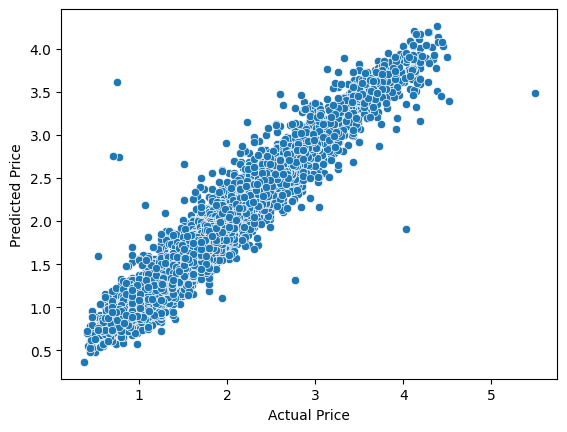

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
for col in df1.columns:
    print(col, df1[col].nunique())

region 613
price 2721
manufacturer 32
model 353
cylinders 11
fuel 7
odometer 30614
transmission 2
drive 7
type 11
seats 10
engine_cc 185
max_power 553
age 35


# **Exporting the Model**

In [ ]:
import joblib

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), ['cylinders', 'odometer', 'seats', 'engine_cc', 'max_power', 'age']),
        ('cat1', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), columns_to_oe),
        ('cat2', OneHotEncoder(handle_unknown= 'ignore'), columns_to_ohe)
    ]
)

In [ ]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=125,
        max_depth=20,
        n_jobs=-1,
        random_state=42,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt'
    ))
])

rf_pipeline.fit(X_train_df1, y_train_df1)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['cylinders', 'odometer',
                                                   'seats', 'engine_cc',
                                                   'max_power', 'age']),
                                                 ('cat1',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['manufacturer', 'model']),
                                                 ('cat2',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['fuel', 'drive',
                                                   'transmission', 'type'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, max_features='sqrt',
                                       n_estimators=125, n_jobs=-1,
                                       random_state=42))])

In [ ]:
X_train_df1.columns

Index(['region', 'manufacturer', 'model', 'cylinders', 'fuel', 'odometer',
       'transmission', 'drive', 'type', 'seats', 'engine_cc', 'max_power',
       'age'],
      dtype='object')

In [ ]:
joblib.dump(rf_pipeline, "car_model.pkl", compress=9)

['car_model.pkl']

In [ ]:
joblib.dump(df, "cars_dataframe.pkl")

['cars_dataframe.pkl']

In [ ]:
df = joblib.load('cars_dataframe.pkl')

In [ ]:
df.head()

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
0,agra,1.811562,tata,tiago,3,petrol,20979,manual,fwd,hatchback,5,1199,84.88,5
1,agra,2.134166,maruti suzuki,baleno,4,petrol,20176,manual,fwd,hatchback,5,1197,81.86,3
2,agra,1.731656,hyundai,grand i10,3,cng,41448,manual,fwd,hatchback,5,1197,81.86,7
3,agra,1.865629,maruti suzuki,celerio,3,petrol,8527,manual,fwd,hatchback,5,998,67.04,3
4,agra,1.663926,hyundai,santro,4,cng,102049,manual,fwd,hatchback,5,1086,68.05,5


In [ ]:
model = joblib.load('car_model.pkl')

In [ ]:
sample = pd.DataFrame({
    'manufacturer':['maruti suzuki'],
    'model':['swift'],
    'region':['jaipur'],
    'fuel':['petrol'],
    'transmission':['manual'],
    'drive':['fwd'],
    'type':['hatchback'],
    'cylinders':[4],
    'engine_cc':[1199],
    'max_power':[82],
    'odometer':[46500],
    'age':[7],
    'seats':[5]
})

pred = model.predict(sample)

In [ ]:
import numpy as np

price = pred[0]
print(price)

485188.97866428946


In [ ]:
X_train['transmission'].value_counts(normalize = True)

,proportion
transmission,
manual,0.761495
automatic,0.238505


In [ ]:
df1.columns

Index(['region', 'price', 'manufacturer', 'model', 'cylinders', 'fuel',
       'odometer', 'transmission', 'drive', 'type', 'seats', 'engine_cc',
       'max_power', 'age'],
      dtype='object')

In [ ]:
df1[(df1['model'] == 'swift') & (df['fuel'] == 'petrol')]

,region,price,manufacturer,model,cylinders,fuel,odometer,transmission,drive,type,seats,engine_cc,max_power,age
75,ambala,1.690096,maruti suzuki,swift,4,petrol,55356,manual,fwd,hatchback,5,1197.0,81.86,8
284,bangalore,1.497388,maruti suzuki,swift,4,petrol,100981,manual,fwd,hatchback,5,1197.0,81.86,13
417,bangalore,1.969906,maruti suzuki,swift,4,petrol,66898,automatic,fwd,hatchback,5,1197.0,81.86,6
463,bangalore,1.506297,maruti suzuki,swift,4,petrol,77663,manual,fwd,hatchback,5,1197.0,81.86,12
484,bangalore,1.633154,maruti suzuki,swift,4,petrol,53328,manual,fwd,hatchback,5,1197.0,81.86,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58083,pune,1.118415,maruti suzuki,swift,4,petrol,73755,manual,fwd,hatchback,5,1298.0,88.20,16
58091,pune,1.504077,maruti suzuki,swift,4,petrol,53127,manual,fwd,hatchback,5,1197.0,85.80,14
58092,pune,1.508512,maruti suzuki,swift,4,petrol,23087,manual,fwd,hatchback,5,1197.0,81.80,12
58106,pune,1.481605,maruti suzuki,swift,4,petrol,48791,manual,fwd,hatchback,5,1197.0,81.80,12


In [ ]:
np.expm1(1.690096)

np.float64(4.4200010002526655)

# **Testing the model performance with hyperopt**

In [ ]:
!pip install hyperopt

In [ ]:
!pip install hpsklearn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.8 MB/s eta 0:00:00
  Created wheel for hpsklearn: filename=hpsklearn-0.1.0-py3-none-any.whl size=23916 sha256=4bb766b1a4583099b3340cb4cc81cce093d01c0cc2f1dd46cededd898263d7eb
  Stored in directory: /root/.cache/pip/wheels/08/6b/8c/977f9f05e977944f6ef84184cf00dd08d059eb04dfe0c1fb9c
Successfully built hpsklearn


In [ ]:
from hyperopt import tpe
from hpsklearn import HyperoptEstimator
from hpsklearn import any_regressor
from hpsklearn import any_preprocessing

WARN: OMP_NUM_THREADS=None =>
... If you are using openblas if you are using openblas set OMP_NUM_THREADS=1 or risk subprocess calls hanging indefinitely


In [ ]:
model = HyperoptEstimator(regressor=any_regressor('reg'), preprocessing=any_preprocessing('pre'), algo=tpe.suggest, max_evals=50, trial_timeout=30)

AttributeError: module 'inspect' has no attribute 'getargspec'

### Using `hyperopt` directly for RandomForestRegressor

To use `hyperopt` directly, you need to define:
1.  **A search space**: This specifies the range and type of hyperparameters `hyperopt` should explore.
2.  **An objective function**: This function takes a set of hyperparameters, trains a model with them, and returns a metric (e.g., negative R2 score, MAE) to be minimized.
3.  **The `fmin` function**: This is the core `hyperopt` function that runs the optimization process.

# **Random Forest Regressor scoring with hyperparameter tuning**

In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from sklearn.metrics import r2_score

# Define the search space for RandomForestRegressor
space = {
    'n_estimators': hp.quniform('n_estimators', 100, 600, 100), # Number of trees
    'max_depth': hp.choice('max_depth', [None, 10, 20, 30]),    # Maximum depth of the tree
    'min_samples_split': hp.quniform('min_samples_split', 2, 10, 1), # Minimum number of samples required to split an internal node
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 5, 1),   # Minimum number of samples required to be at a leaf node
    'max_features': hp.choice('max_features', ['sqrt', 'log2', 0.8, 1.0]) # Number of features to consider when looking for the best split
}

# Objective function to minimize (negative R2 score)
def objective(params):
    n_estimators = int(params['n_estimators'])
    min_samples_split = int(params['min_samples_split'])
    min_samples_leaf = int(params['min_samples_leaf'])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=params['max_depth'],
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=params['max_features'],
        n_jobs=-1, # Use all available cores
        random_state=42
    )

    # Create a pipeline with the existing preprocessor and the current model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    # Hyperopt minimizes the objective function, so we return negative R2
    score = r2_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK, 'params': params}

# Run the optimization
trials = Trials()
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=50, # Number of different hyperparameter combinations to try
            trials=trials,
            rstate=np.random.default_rng(42) # For reproducibility
           )

print("Best parameters found:", best)


100%|██████████| 50/50 [18:30<00:00, 22.22s/trial, best loss: -0.9342636775370158]
Best parameters found: {'max_depth': np.int64(3), 'max_features': np.int64(0), 'min_samples_leaf': np.float64(1.0), 'min_samples_split': np.float64(3.0), 'n_estimators': np.float64(500.0)}


After `fmin` completes, `best` will contain the indices of the best parameters found in the `space`. We can then map these back to their actual values.

In [ ]:
from hyperopt import space_eval

best_params = space_eval(space, best)
print("Best actual parameters:", best_params)

# Train the final model with the best parameters
final_rf_model = RandomForestRegressor(
    n_estimators=int(best_params['n_estimators']),
    max_depth=best_params['max_depth'],
    min_samples_split=int(best_params['min_samples_split']),
    min_samples_leaf=int(best_params['min_samples_leaf']),
    max_features=best_params['max_features'],
    n_jobs=-1,
    random_state=42
)

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', final_rf_model)
])

final_pipeline.fit(X_train, y_train)
y_pred_final = final_pipeline.predict(X_test)

print("\nR2 score with best parameters:", r2_score(y_test, y_pred_final))
print("MAE with best parameters:", mean_absolute_error(y_test, y_pred_final))


Best actual parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1.0, 'min_samples_split': 3.0, 'n_estimators': 500.0}

R2 score with best parameters: 0.9342636775370158
MAE with best parameters: 0.11522815297424159
